## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv")

## Dataset Overview

In [3]:
df.shape

(918, 12)

In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [7]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [8]:
df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
426,56,M,ATA,126,166,0,ST,140,N,0.0,Up,0
679,63,M,TA,145,233,1,LVH,150,N,2.3,Down,0
391,70,M,ASY,115,0,0,ST,92,Y,0.0,Flat,1
778,58,M,ASY,128,259,0,LVH,130,Y,3.0,Flat,1
161,49,M,ASY,128,212,0,Normal,96,Y,0.0,Flat,1


In [9]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


## Missing Values

In [10]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## Preprocessing

In [11]:
df.rename(columns={'Sex':'Gender'}, inplace=True)

In [12]:
df

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## Duplicate Rows

In [13]:
df[df.duplicated()]

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


## Numerical Analysis

In [14]:
df["Age"].describe()

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64

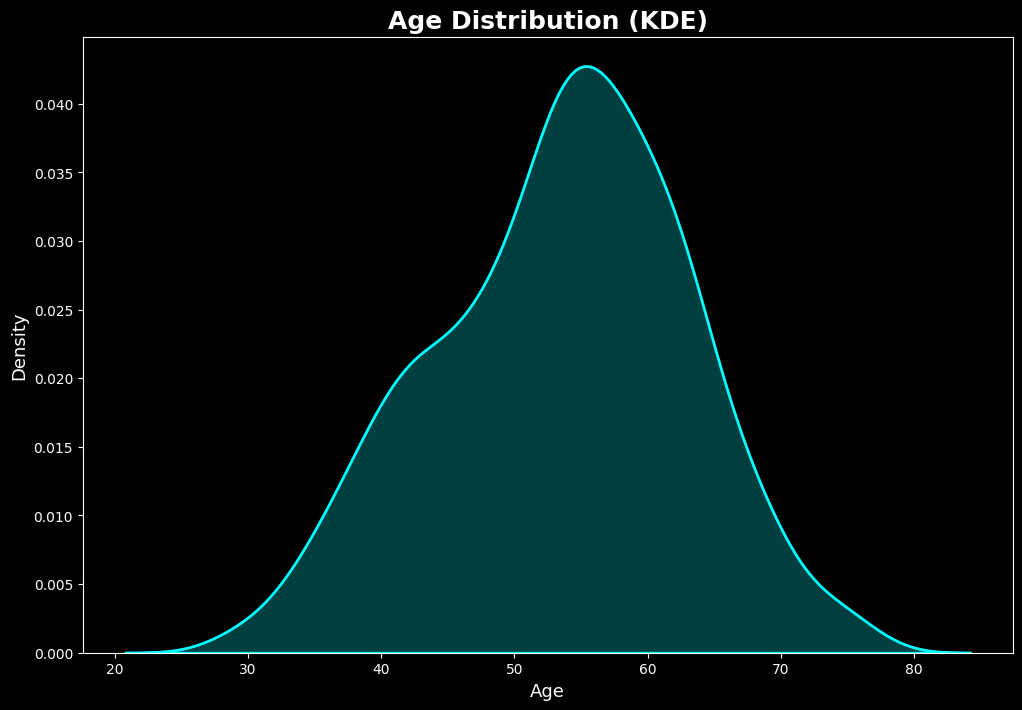

In [15]:
plt.style.use("dark_background")
plt.figure(figsize=(12,8))
sns.kdeplot(
    data=df,
    x="Age",
    fill=True,
    linewidth=2,
    color="cyan"
)
plt.title("Age Distribution (KDE)", fontsize=18, weight="bold")
plt.xlabel("Age", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.show()

#### insight

The patients' ages are centered around 54 years, with the mean (53.5) being very close to the median (54), indicating a nearly symmetric distribution. Half of the patients are between 47 and 60 years old, while the overall age range spans from 28 to 77 years, suggesting that the dataset mainly represents middle-aged and older adults.

In [16]:
df["RestingBP"].describe()

count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

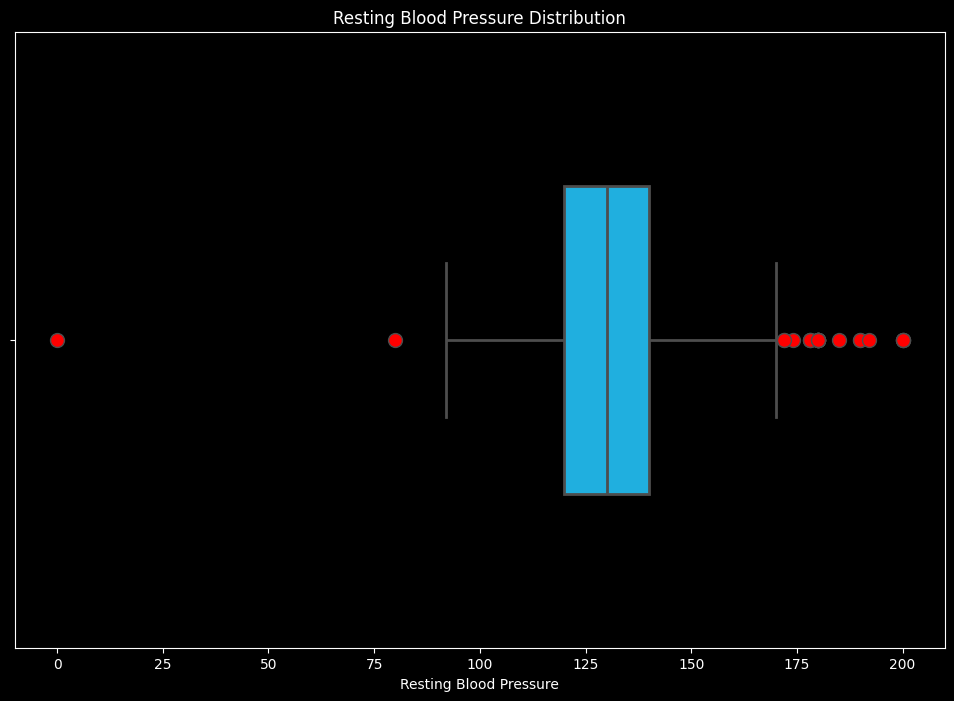

In [17]:
plt.style.use("dark_background")
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x="RestingBP",color="#00BFFF",width=0.5,linewidth=2,
    flierprops={"marker": "o","markerfacecolor": "red","markersize": 10,} )
plt.xlabel("Resting Blood Pressure")
plt.title("Resting Blood Pressure Distribution")
plt.show()

#### insight

The Resting Blood Pressure (RestingBP) values are centered around 130 mmHg, with a mean of 132.4 mmHg and a median of 130 mmHg, indicating a relatively balanced distribution. Approximately 50% of the patients have resting blood pressure values between 120 and 140 mmHg. However, the presence of a minimum value of 0 mmHg is medically unrealistic and likely represents missing or incorrectly recorded data that should be addressed during data preprocessing.

In [18]:
df["Cholesterol"].describe()

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

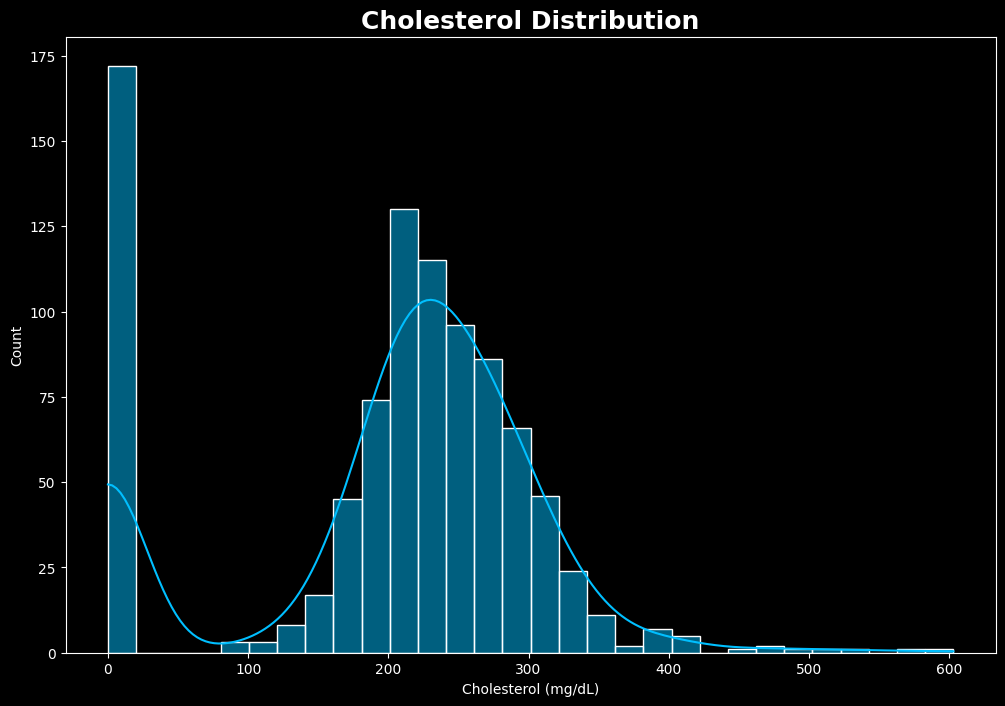

In [19]:
plt.style.use("dark_background")
plt.figure(figsize=(12,8))
sns.histplot(
        data=df,
        x="Cholesterol",
        bins=30,
        kde=True,
        color="deepskyblue"
)
plt.title("Cholesterol Distribution", fontsize=18, weight="bold")
plt.xlabel("Cholesterol (mg/dL)")
plt.ylabel("Count")
plt.show()

In [20]:
zero_count = (df["Cholesterol"] == 0).sum()
zero_percentage = (df["Cholesterol"] == 0).mean() * 100
print(f"Zero Cholesterol Values : {zero_count}")
print(f"Percentage : {zero_percentage:.2f}%")

Zero Cholesterol Values : 172
Percentage : 18.74%


#### Insight

Approximately 18.74% of the records contain a cholesterol value of 0 mg/dL, which is medically unrealistic. These values are likely placeholders for missing or incorrectly recorded data. Therefore, they should be carefully considered during the data preprocessing stage before building a machine learning model.

In [21]:
df["MaxHR"].describe()

count    918.000000
mean     136.809368
std       25.460334
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: MaxHR, dtype: float64

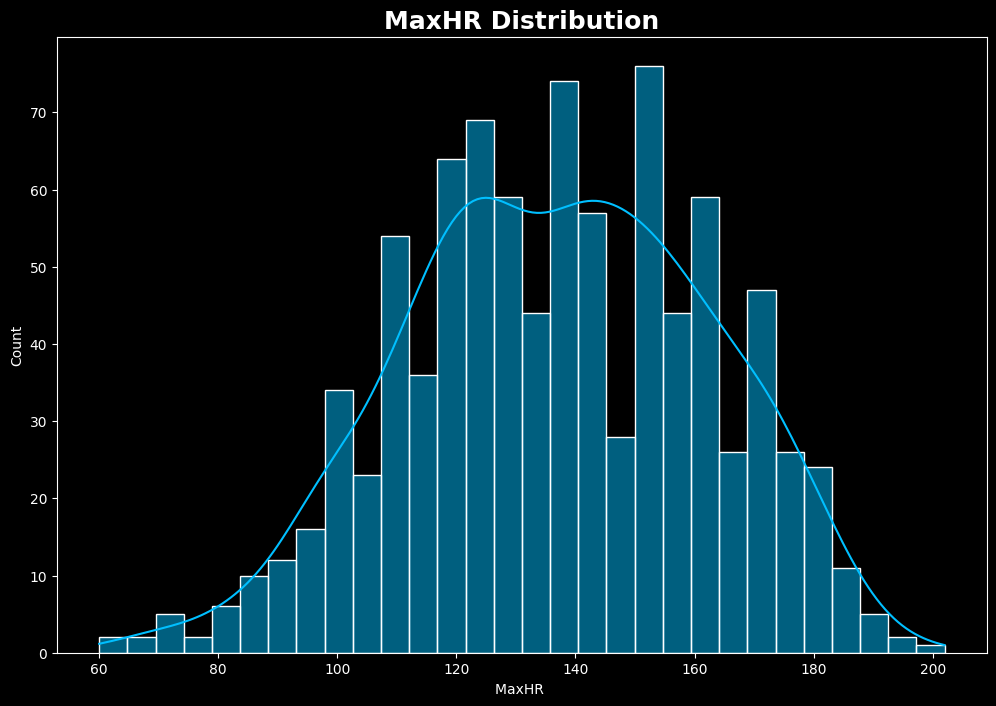

In [22]:
plt.style.use("dark_background")
plt.figure(figsize=(12,8))
sns.histplot(
        data=df,
        x="MaxHR",
        bins=30,
        kde=True,
        color="deepskyblue"
)
plt.title("MaxHR Distribution", fontsize=18, weight="bold")
plt.xlabel("MaxHR ")
plt.ylabel("Count")
plt.show()

#### insight

The Maximum Heart Rate (MaxHR) values are centered around 137 bpm, with the mean (136.8) being very close to the median (138), suggesting a nearly symmetric distribution. Half of the patients achieved a maximum heart rate between 120 and 156 bpm, while the observed values range from 60 to 202 bpm, indicating moderate variability across patients.

In [23]:
df["Oldpeak"].describe()

count    918.000000
mean       0.887364
std        1.066570
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

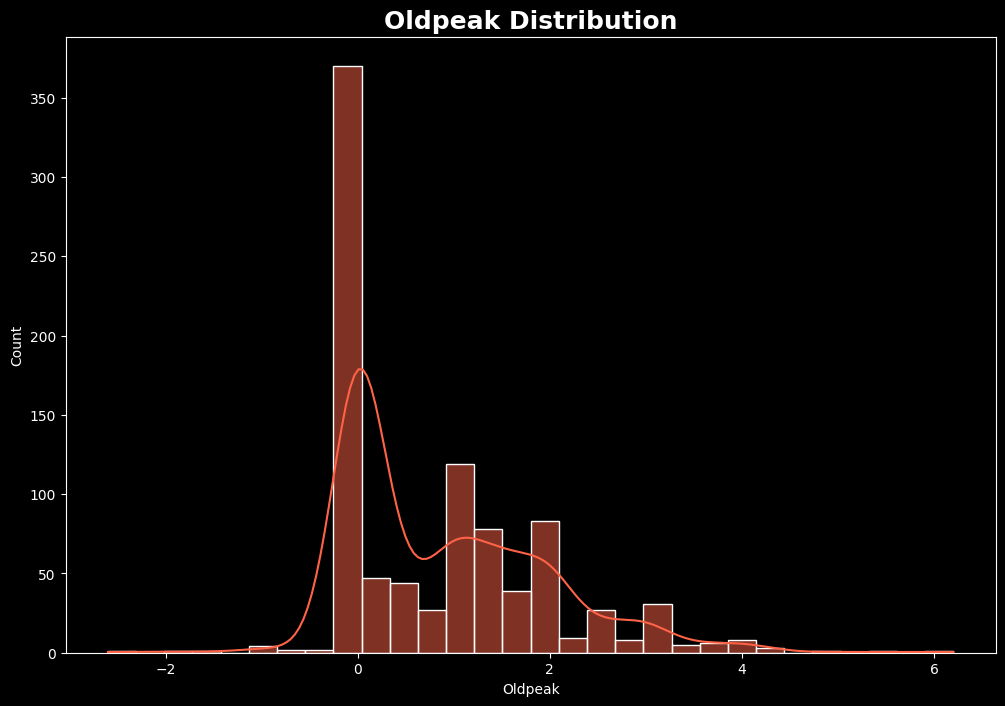

In [24]:
plt.style.use("dark_background")
plt.figure(figsize=(12,8))
sns.histplot(
    data=df,
    x="Oldpeak",
    bins=30,
    kde=True,
    color="tomato"
)
plt.title("Oldpeak Distribution", fontsize=18, weight="bold")
plt.xlabel("Oldpeak")
plt.ylabel("Count")
plt.show()

#### insight

The Oldpeak values are generally low, with a mean of 0.89 and a median of 0.60, indicating that most patients experienced only a small ST-segment depression during exercise. However, the distribution includes a few high values (up to 6.2), suggesting the presence of patients with more pronounced ST depression.

##  Categorical Analysis


In [25]:
df["HeartDisease"].value_counts().reset_index()


,HeartDisease,count
0,1,508
1,0,410


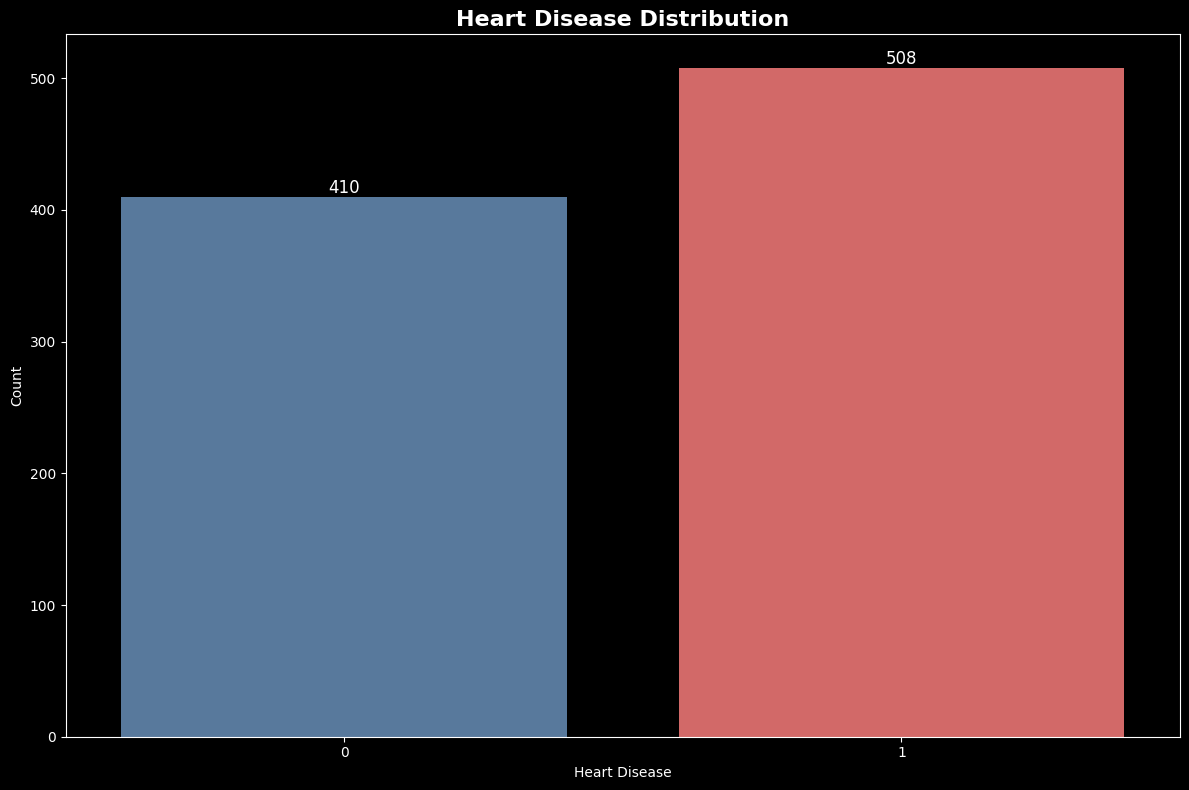

In [26]:
plt.style.use("dark_background")
plt.figure(figsize=(12,8))
ax =sns.countplot(
    data=df,
    x="HeartDisease",
    palette=["#4C78A8", "#E45756"]
)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=12)
plt.title("Heart Disease Distribution", fontsize=16, weight="bold")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [27]:
df["Gender"].value_counts().reset_index()

,Gender,count
0,M,725
1,F,193


In [28]:
gender=df["Gender"].value_counts(normalize=True).mul(100).round(2).reset_index()
gender.columns = ["Gender", "Count"]

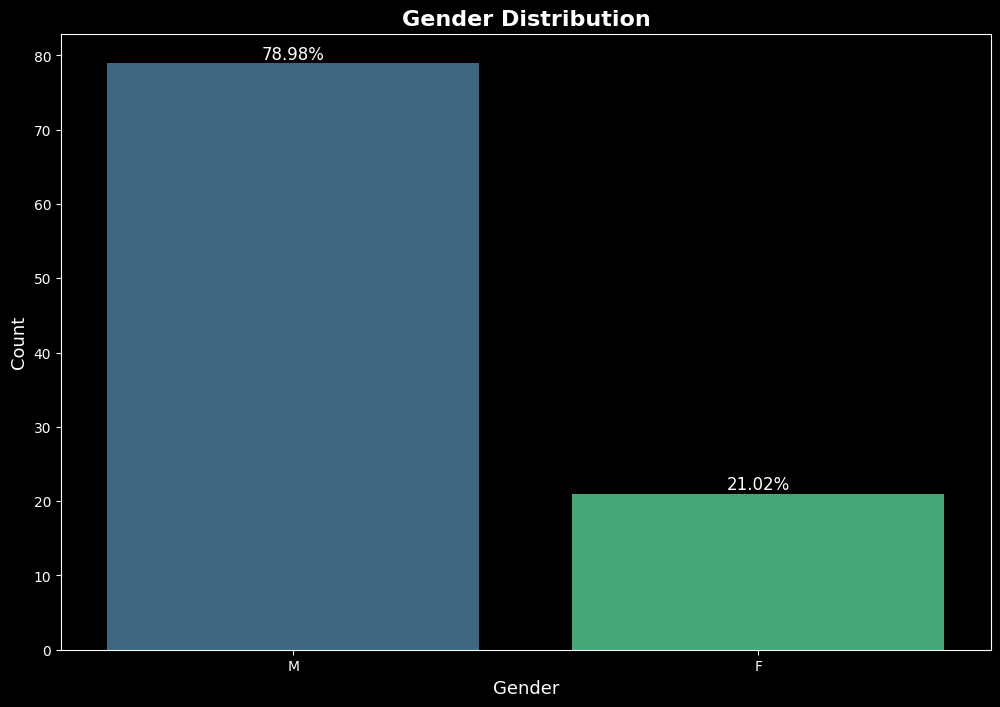

In [29]:
plt.style.use("dark_background")
plt.figure(figsize=(12,8))
ax = sns.barplot(data=gender,x="Gender",y="Count",palette="viridis")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", fontsize=12)
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.title("Gender Distribution", fontsize=16, weight="bold")
plt.show()

In [30]:
df["ChestPainType"].value_counts().reset_index()

,ChestPainType,count
0,ASY,496
1,NAP,203
2,ATA,173
3,TA,46


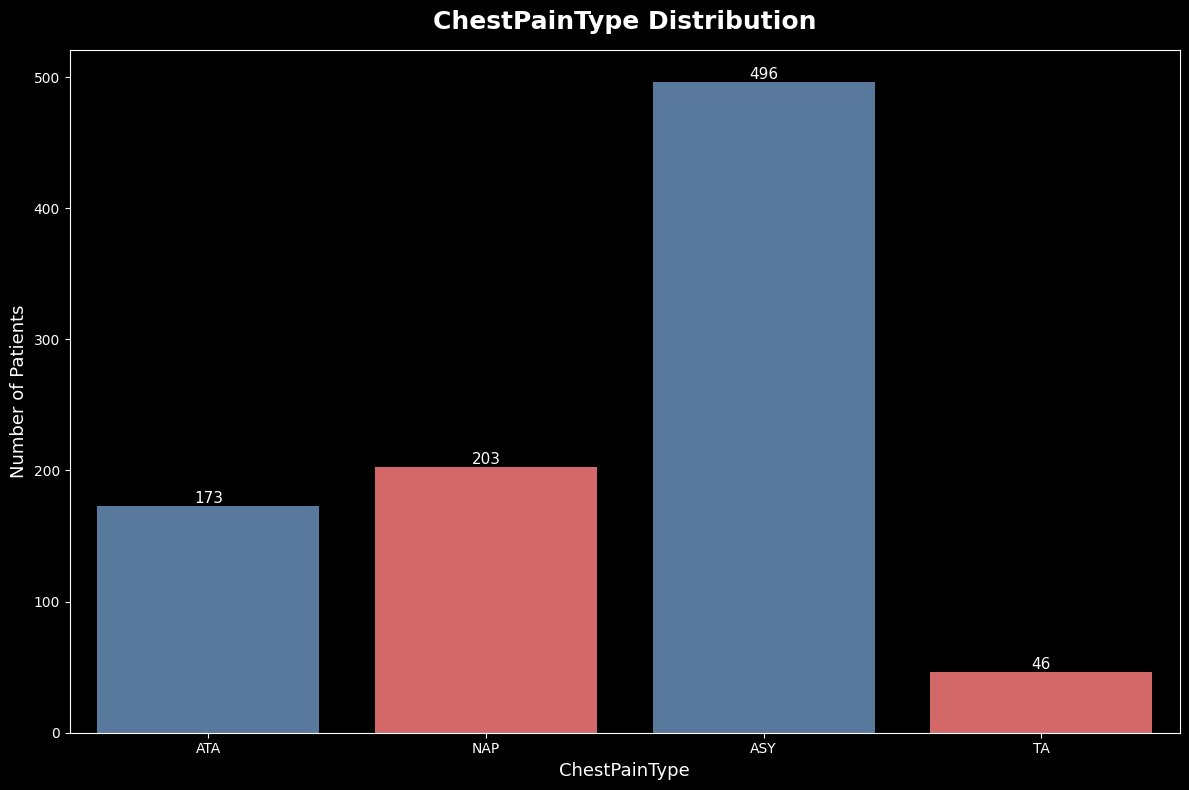

In [31]:
plt.style.use("dark_background")

plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=df,
    x="ChestPainType",
    palette=["#4C78A8", "#E45756"]   )

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.title("ChestPainType Distribution", fontsize=18, weight="bold", pad=15)
plt.xlabel("ChestPainType", fontsize=13)
plt.ylabel("Number of Patients", fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
df["RestingECG"].value_counts().reset_index()

,RestingECG,count
0,Normal,552
1,LVH,188
2,ST,178


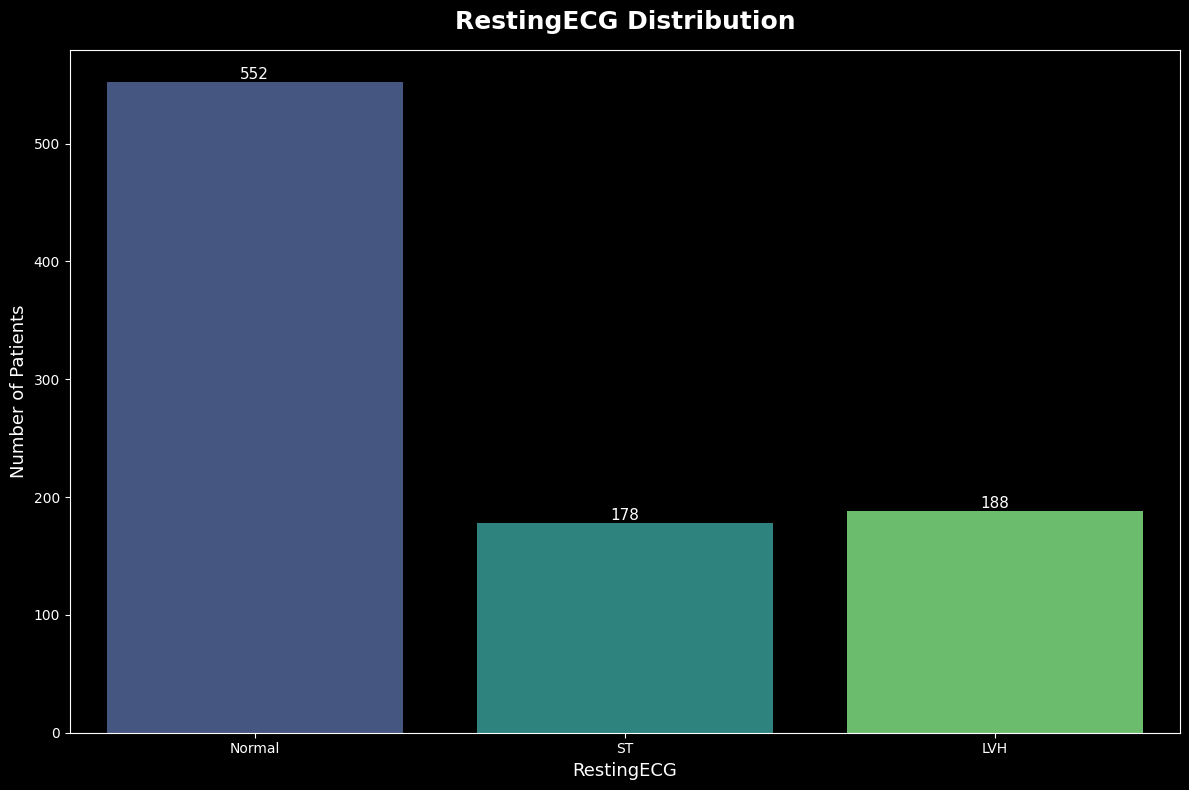

In [33]:
plt.style.use("dark_background")

plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=df,
    x="RestingECG",
    palette="viridis")

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.title("RestingECG Distribution", fontsize=18, weight="bold", pad=15)
plt.xlabel("RestingECG", fontsize=13)
plt.ylabel("Number of Patients", fontsize=13)
plt.tight_layout()
plt.show()

In [34]:
df["ExerciseAngina"].value_counts().reset_index()

,ExerciseAngina,count
0,N,547
1,Y,371


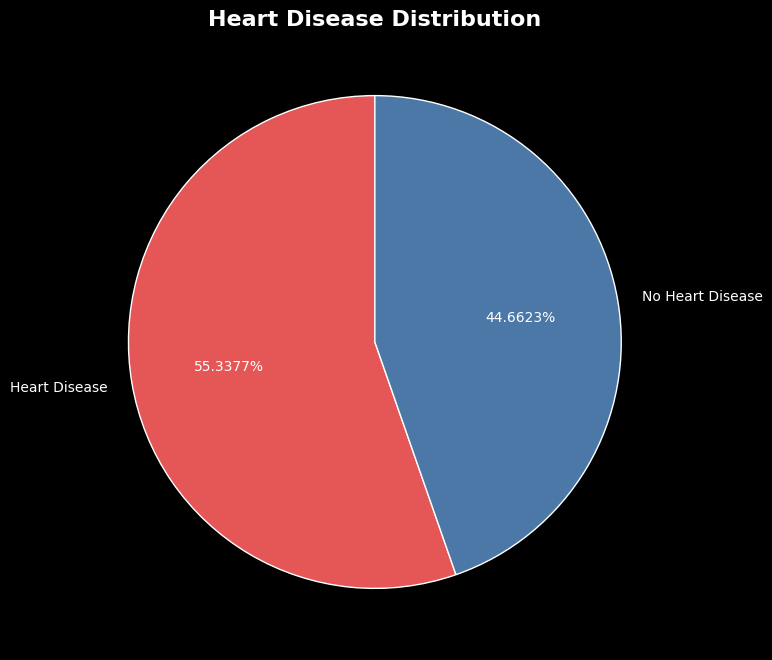

In [35]:
plt.style.use("dark_background")

heart = df["HeartDisease"].value_counts()

plt.figure(figsize=(12,8))

plt.pie(
    heart,
    labels=["Heart Disease", "No Heart Disease"],
    autopct="%1.4f%%",
    startangle=90,
    colors=["#E45756", "#4C78A8"],
    wedgeprops={"edgecolor": "white"}
)

plt.title("Heart Disease Distribution", fontsize=16, weight="bold")

plt.show()

In [36]:
df["ST_Slope"].value_counts().reset_index()


,ST_Slope,count
0,Flat,460
1,Up,395
2,Down,63


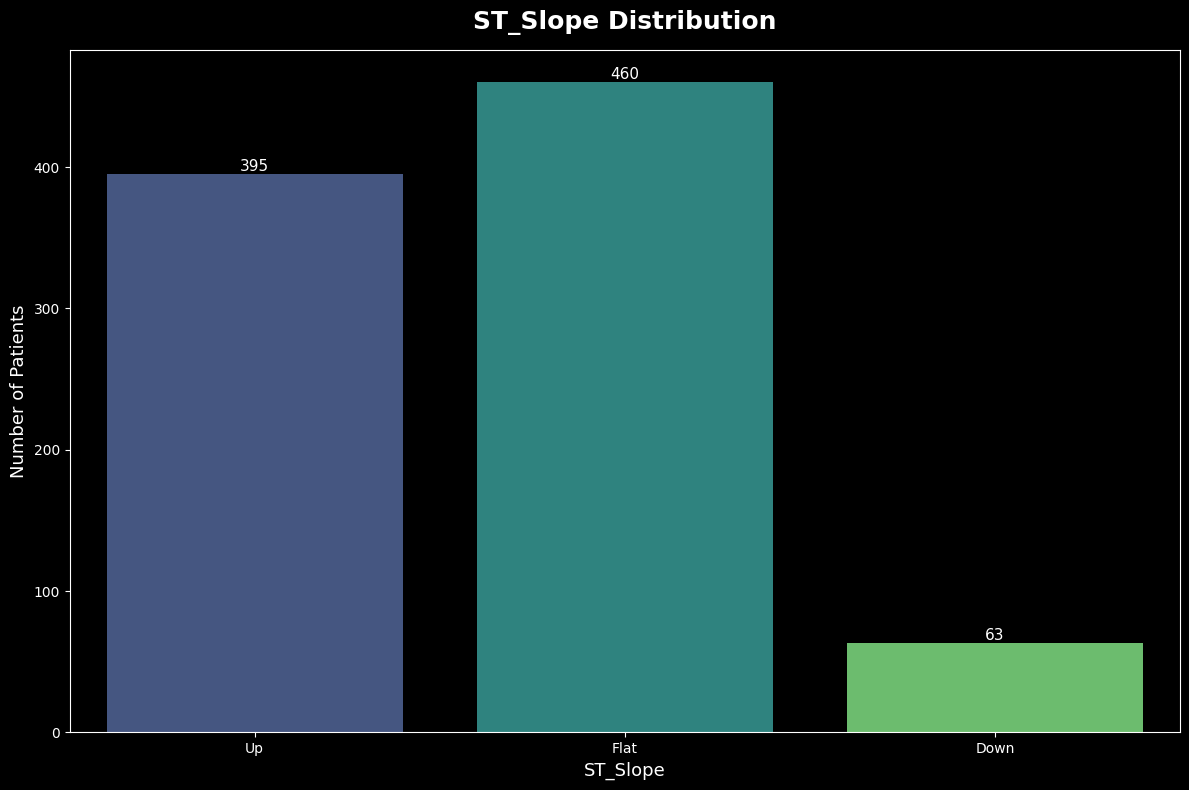

In [37]:
plt.style.use("dark_background")

plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=df,
    x="ST_Slope",
    palette="viridis")

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.title("ST_Slope Distribution", fontsize=18, weight="bold", pad=15)
plt.xlabel("ST_Slope", fontsize=13)
plt.ylabel("Number of Patients", fontsize=13)
plt.tight_layout()
plt.show()

In [38]:
df["FastingBS"].value_counts().reset_index()


,FastingBS,count
0,0,704
1,1,214


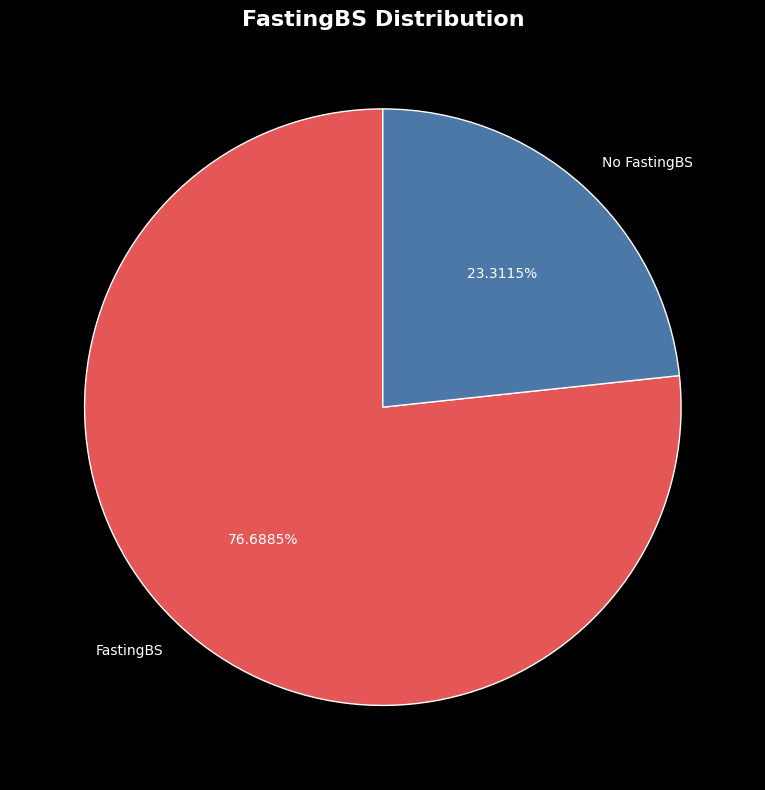

In [39]:
plt.style.use("dark_background")

FastingBS = df["FastingBS"].value_counts()

plt.figure(figsize=(12,8))

plt.pie(
    FastingBS,
    labels=["FastingBS", "No FastingBS"],
    autopct="%1.4f%%",
    startangle=90,
    colors=["#E45756", "#4C78A8"],
    wedgeprops={"edgecolor": "white"}
)

plt.title("FastingBS Distribution", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

## Bivariate Analysis

#### Age vs HeartDisease

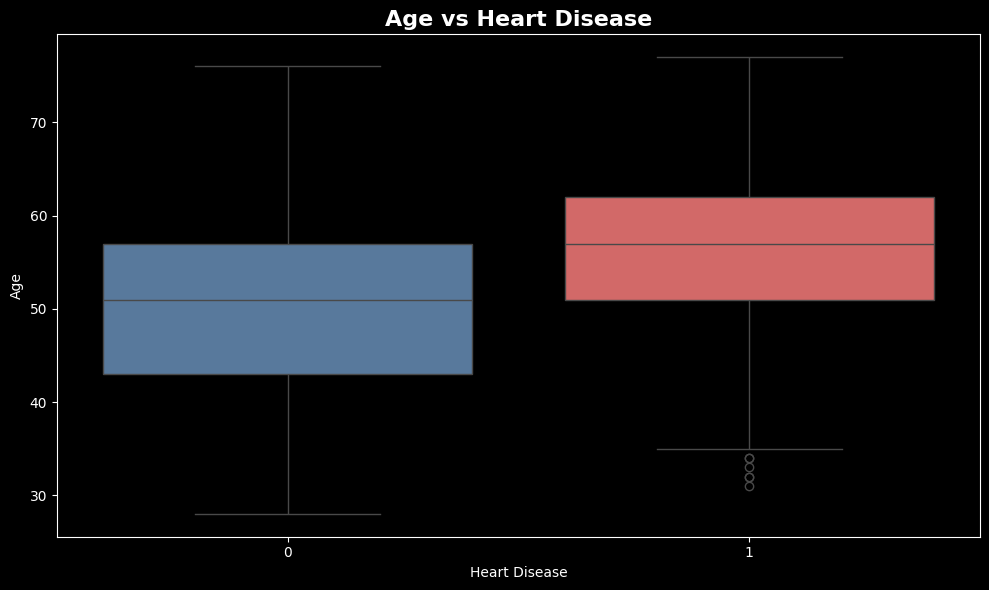

In [40]:
plt.style.use("dark_background")
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Age",
    palette=["#4C78A8", "#E45756"]
)

plt.title("Age vs Heart Disease", fontsize=16, weight="bold")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

### insight

The heart disease group has a higher median age than the non-heart disease group, suggesting that older patients are more likely to have heart disease. However, the overlap between the two groups indicates that age is an important factor but not the only predictor of heart disease.

### Gender vs HeartDisease

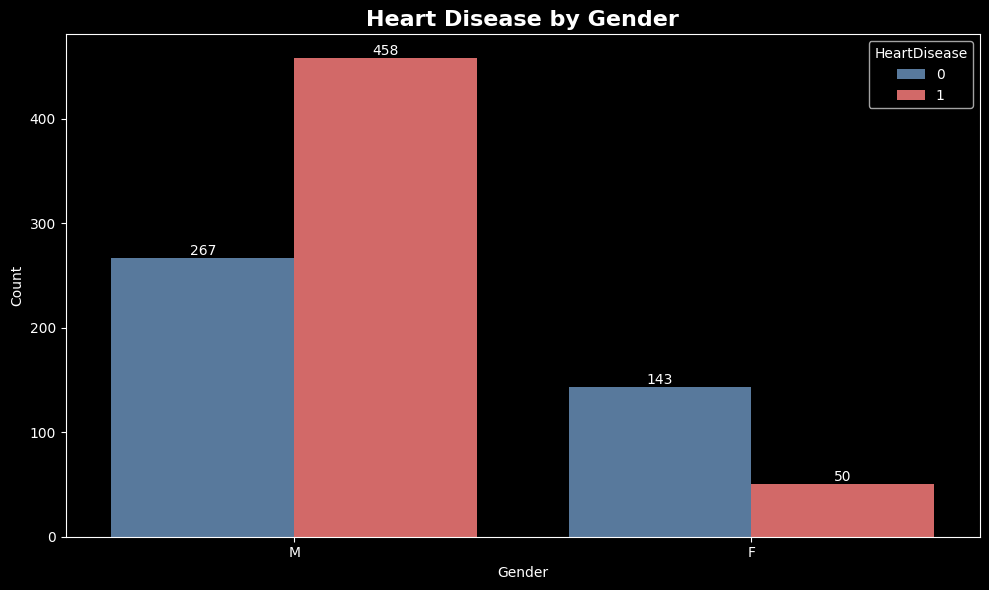

In [41]:
 plt.style.use("dark_background")
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="Gender",
    hue="HeartDisease",
    palette=["#4C78A8", "#E45756"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Heart Disease by Gender", fontsize=16, weight="bold")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### insight

Male patients show a noticeably higher prevalence of heart disease than female patients in this dataset. Among males, the number of patients diagnosed with heart disease exceeds those without the disease, whereas among females, most patients are not diagnosed with heart disease. This suggests that gender may be an important factor associated with heart disease in this dataset.

### ChestPainType vs HeartDisease

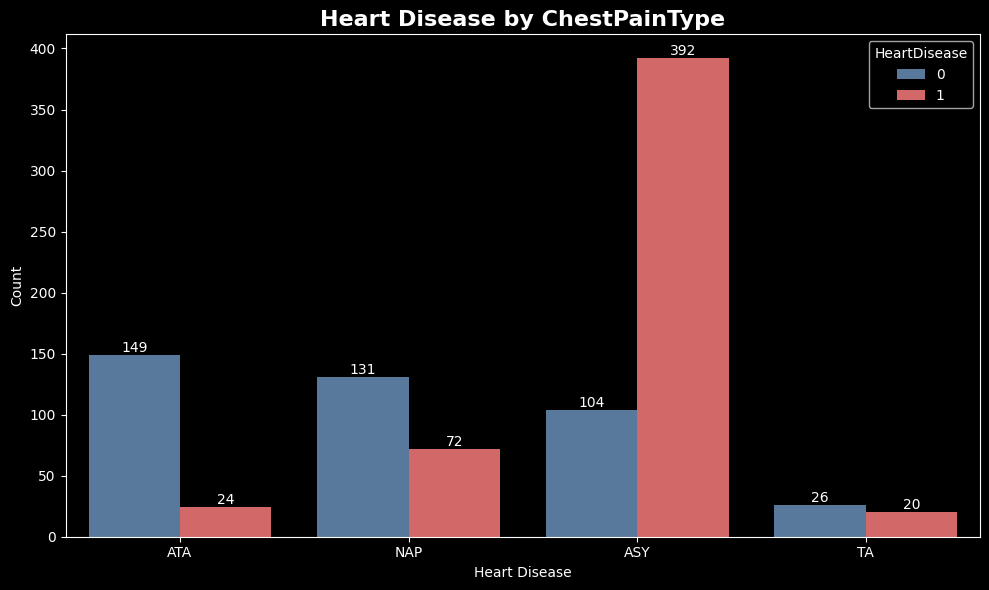

In [42]:
 plt.style.use("dark_background")
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="ChestPainType",
    hue="HeartDisease",
    palette=["#4C78A8", "#E45756"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Heart Disease by ChestPainType", fontsize=16, weight="bold")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### ExerciseAngina vs HeartDisease

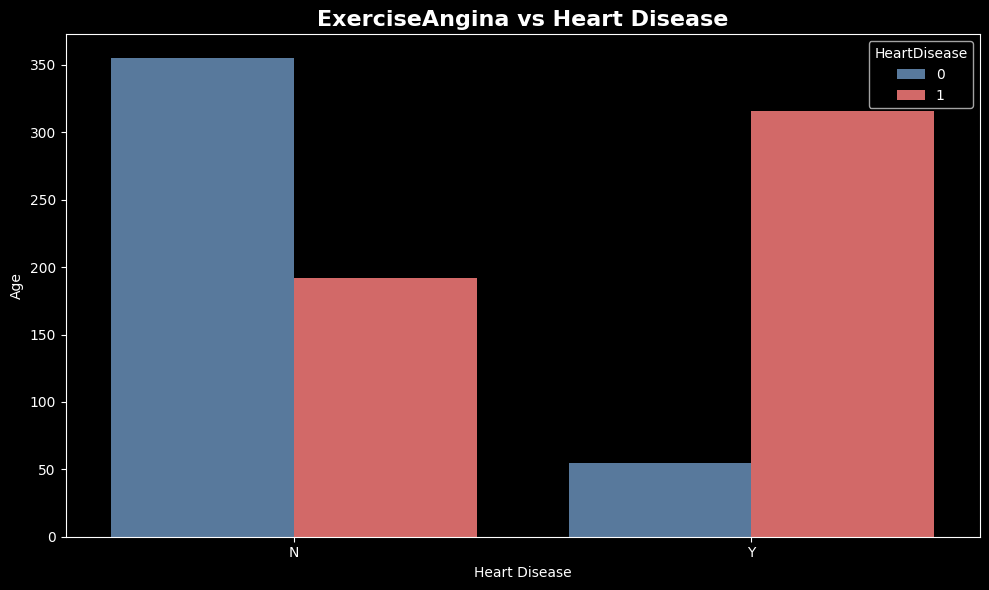

In [43]:
plt.style.use("dark_background")
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="ExerciseAngina",
    hue="HeartDisease",
    palette=["#4C78A8", "#E45756"]
)

plt.title("ExerciseAngina vs Heart Disease", fontsize=16, weight="bold")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

### insight

Patients who experience exercise-induced angina (ExerciseAngina = Yes) are much more likely to have heart disease compared to those who do not experience angina during exercise. Conversely, most patients without exercise-induced angina are not diagnosed with heart disease. This suggests that ExerciseAngina is a strong predictor of heart disease in this dataset.